# Notebook 001 — ECA Rule Space Exploration

**Repository:** `cellauto-lab` | **Project:** SYNTRAN Labs | **Status:** Incubation — private

---

## Research Question

> Can an LLM-assisted workflow systematically explore the 256 elementary cellular automaton (ECA) rules,
> measure emergent behavioral properties, generate structured experiment summaries, and support
> falsifiable hypothesis generation — while maintaining reproducibility, auditability, and honest
> epistemic standards?

This notebook establishes the baseline simulation and metric infrastructure for `cellauto-lab`.

### Scope

- Simulate all 256 Wolfram ECA rules under identical conditions
- Extract interpretable behavioral metrics from each simulation
- Rank rules by a heuristic behavioral interest score
- Generate structured summaries ready for later LLM review

### Out of Scope

- Mathematical proofs from visual output
- Claims requiring empirical validation outside simulation
- External API calls or LLM inference inside this notebook

In [1]:
import sys
from pathlib import Path

# Resolve src/ whether notebook is opened from project root or notebooks/
for _p in [Path('src'), Path('../src')]:
    _resolved = _p.resolve()
    if _resolved.exists() and str(_resolved) not in sys.path:
        sys.path.insert(0, str(_resolved))

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from cellauto_lab.rules import rule_table, validate_rule, neighborhood_ordering
from cellauto_lab.simulator import simulate, initial_state
from cellauto_lab.metrics import compute_metrics
from cellauto_lab.reporting import experiment_summary, summaries_to_json

print('Imports OK')
print(f'NumPy {np.__version__} | Pandas {pd.__version__}')

Imports OK
NumPy 2.2.6 | Pandas 2.3.1


In [2]:
# Experiment Configuration
N_CELLS = 100
N_STEPS = 200
INITIAL_CONDITION = 'single_seed'
RANDOM_SEED = 42
BOUNDARY = 'fixed_zero'

KNOWN_RULES = [0, 30, 90, 110, 184, 255]

print(f'Grid: {N_CELLS} cells x {N_STEPS} steps')
print(f'Initial condition: {INITIAL_CONDITION}')
print(f'Boundary: {BOUNDARY}')
print(f'Known test rules: {KNOWN_RULES}')

Grid: 100 cells x 200 steps
Initial condition: single_seed
Boundary: fixed_zero
Known test rules: [0, 30, 90, 110, 184, 255]


## Rule Encoding

Wolfram elementary cellular automata use a 3-cell neighborhood `(left, center, right)`.
There are `2^3 = 8` possible neighborhoods, ordered by their index value from 7 (`111`) down to 0 (`000`).

A Wolfram rule number encodes the next center-cell state for each neighborhood as a single 8-bit integer:

- Neighborhood index `i = left*4 + center*2 + right`
- Bit `i` of the rule number → output for that neighborhood

**Example: Rule 30 = `00011110` in binary**

| Neighborhood | Index | Output |
|:---:|:---:|:---:|
| 1 1 1 | 7 | 0 |
| 1 1 0 | 6 | 0 |
| 1 0 1 | 5 | 0 |
| 1 0 0 | 4 | 1 |
| 0 1 1 | 3 | 1 |
| 0 1 0 | 2 | 1 |
| 0 0 1 | 1 | 1 |
| 0 0 0 | 0 | 0 |

Boundary condition: **fixed_zero** — cells outside the grid boundary are treated as 0.

In [3]:
# Inspect rule tables for two reference rules
for rule_num in [30, 110]:
    print()
    print(f'Rule {rule_num} = {rule_num:08b}b')
    print('  {:>14}  {:>5}  {:>6}'.format('Neighborhood', 'Index', 'Output'))
    print('  ' + '-' * 30)
    table = rule_table(rule_num)
    for nbhd in neighborhood_ordering():
        left, center, right = nbhd
        idx = left * 4 + center * 2 + right
        out = table[nbhd]
        nbhd_str = f'({left},{center},{right})'
        print(f'  {nbhd_str:<14}  {idx:>5}  {out:>6}')


Rule 30 = 00011110b
    Neighborhood  Index  Output
  ------------------------------
  (1,1,1)             7       0
  (1,1,0)             6       0
  (1,0,1)             5       0
  (1,0,0)             4       1
  (0,1,1)             3       1
  (0,1,0)             2       1
  (0,0,1)             1       1
  (0,0,0)             0       0

Rule 110 = 01101110b
    Neighborhood  Index  Output
  ------------------------------
  (1,1,1)             7       0
  (1,1,0)             6       1
  (1,0,1)             5       1
  (1,0,0)             4       0
  (0,1,1)             3       1
  (0,1,0)             2       1
  (0,0,1)             1       1
  (0,0,0)             0       0


## Simulation and Visualization

Space-time diagrams show cell states across time:

- **Horizontal axis**: cell position (0 to N_CELLS − 1)
- **Vertical axis**: time step (0 at top, N_STEPS at bottom)
- **Black pixel**: cell state = 1
- **White pixel**: cell state = 0

The six reference rules cover the main behavioral categories: extinction, chaos,
self-similarity, complexity, particle flow, and saturation.

In [4]:
def plot_rule(rule_num: int, grid, ax) -> None:
    '''Plot a space-time diagram on the given axes.'''
    ax.imshow(grid, cmap='binary', interpolation='nearest', aspect='auto')
    ax.set_title(f'Rule {rule_num}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Cell', fontsize=8)
    ax.set_ylabel('Step', fontsize=8)
    ax.tick_params(labelsize=7)

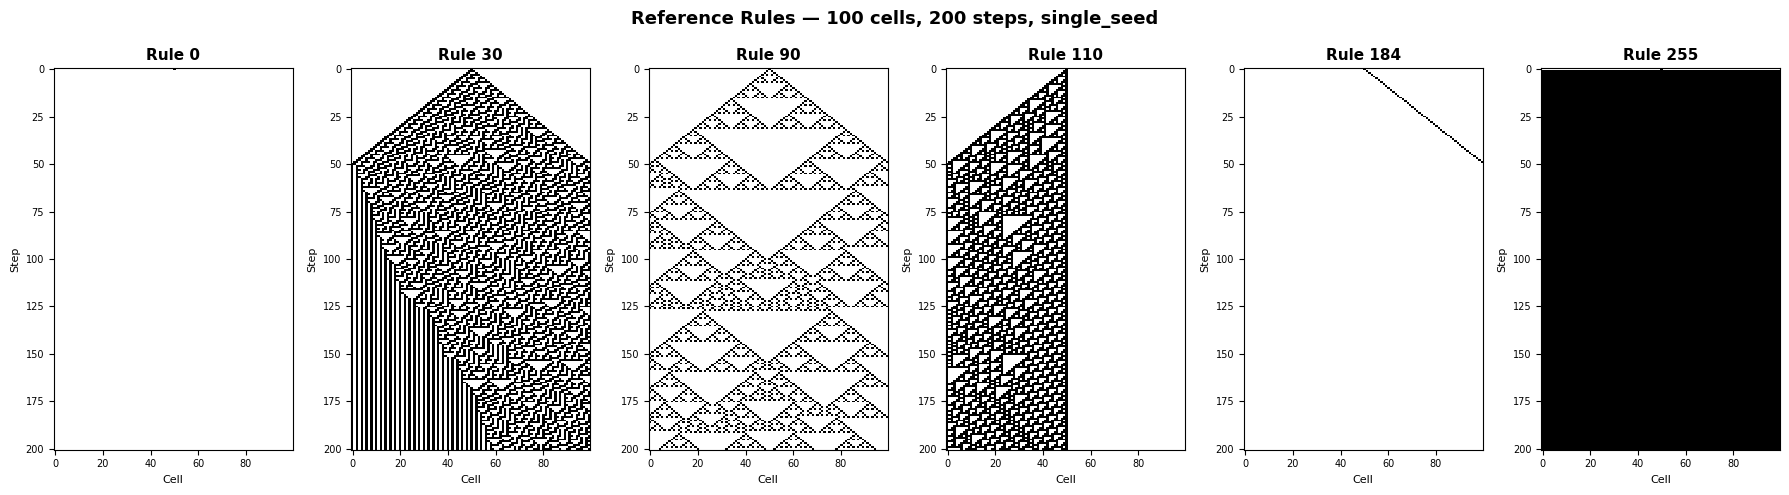

Reference rule visualization complete.


In [5]:
# Simulate and visualize the six reference rules
fig, axes = plt.subplots(1, len(KNOWN_RULES), figsize=(18, 5))
fig.suptitle(
    f'Reference Rules — {N_CELLS} cells, {N_STEPS} steps, {INITIAL_CONDITION}',
    fontsize=13, fontweight='bold'
)

grids = {}
for ax, rule_num in zip(axes, KNOWN_RULES):
    grid = simulate(
        rule_num, n_cells=N_CELLS, n_steps=N_STEPS,
        initial_condition=INITIAL_CONDITION, random_seed=RANDOM_SEED
    )
    grids[rule_num] = grid
    plot_rule(rule_num, grid, ax)

plt.tight_layout()
plt.show()
print('Reference rule visualization complete.')

## Metrics for Reference Rules

Seven metrics are computed from each simulation grid. All are proxies; see `docs/methodology.md` for definitions and known limitations.

| Metric | What it measures |
|---|---|
| `density_mean` | Average fraction of 1s across all time steps |
| `density_final` | Fraction of 1s at the last time step |
| `transition_count` | Mean horizontal state transitions per row |
| `activity_score` | Fraction of cells that change per time step |
| `entropy_score` | Shannon entropy of the row-density distribution |
| `periodicity_score` | Fraction of consecutive identical rows (post-transient) |
| `compression_ratio` | Compressed size / raw size (lower = more regular) |

In [6]:
known_metrics = {}
for rule_num in KNOWN_RULES:
    m = compute_metrics(grids[rule_num])
    known_metrics[rule_num] = m
    dm = m['density_mean']
    df_val = m['density_final']
    tc = m['transition_count']
    ac = m['activity_score']
    en = m['entropy_score']
    pe = m['periodicity_score']
    cr = m['compression_ratio']
    print(
        f'Rule {rule_num:>3}: '
        f'dens={dm:.4f}/{df_val:.4f}  '
        f'trans={tc:.2f}  '
        f'act={ac:.4f}  '
        f'ent={en:.4f}  '
        f'per={pe:.4f}  '
        f'cmp={cr:.4f}'
    )

Rule   0: dens=0.0001/0.0000  trans=0.01  act=0.0001  ent=-0.0000  per=1.0000  cmp=0.0023
Rule  30: dens=0.4460/0.5000  trans=54.28  act=0.3407  ent=1.9596  per=0.0000  cmp=0.1266
Rule  90: dens=0.1395/0.0800  trans=27.70  act=0.2799  ent=1.7281  per=0.0000  cmp=0.0586
Rule 110: dens=0.2581/0.2900  trans=19.21  act=0.1832  ent=1.6221  per=0.0000  cmp=0.0763
Rule 184: dens=0.0025/0.0000  trans=0.49  act=0.0050  ent=-0.0000  per=1.0000  cmp=0.0030
Rule 255: dens=0.9951/1.0000  trans=0.01  act=0.0050  ent=0.0452  per=1.0000  cmp=0.0024


## Full ECA Sweep — All 256 Rules

Simulate every Wolfram rule under identical conditions to build a baseline metric atlas.

**Conditions:** N_CELLS=100, N_STEPS=200, `single_seed`, `fixed_zero`

> This sweep takes a few seconds on a standard laptop.

In [7]:
print('Running full ECA sweep (256 rules)...')

all_metrics = []
all_grids = {}

for rule_num in range(256):
    grid = simulate(
        rule_num, n_cells=N_CELLS, n_steps=N_STEPS,
        initial_condition=INITIAL_CONDITION, random_seed=RANDOM_SEED
    )
    all_grids[rule_num] = grid
    m = compute_metrics(grid)
    m['rule'] = rule_num
    all_metrics.append(m)

print(f'Sweep complete. {len(all_metrics)} rules simulated.')

Running full ECA sweep (256 rules)...
Sweep complete. 256 rules simulated.


In [8]:
# Build pandas DataFrame with all metrics
df = pd.DataFrame(all_metrics).set_index('rule')
cols = [
    'density_mean', 'density_final', 'transition_count',
    'activity_score', 'entropy_score', 'periodicity_score', 'compression_ratio'
]
df = df[cols]

print(f'DataFrame shape: {df.shape}')
display(df.head(10))

DataFrame shape: (256, 7)


,density_mean,density_final,transition_count,activity_score,entropy_score,periodicity_score,compression_ratio
rule,,,,,,,
0,0.000050,0.00,0.0100,0.00005,-0.000000,1.000000,0.002289
1,0.487612,0.01,2.0000,0.98000,0.999982,0.000000,0.005473
2,0.002537,0.00,0.5025,0.00505,-0.000000,0.993333,0.002985
3,0.495075,0.00,0.9801,0.99505,0.999982,0.000000,0.013333
4,0.010000,0.01,2.0000,0.00000,-0.000000,1.000000,0.004826
5,0.492587,0.01,2.9950,0.97000,0.999982,0.000000,0.005572
6,0.011244,0.01,1.2488,0.00500,-0.000000,1.000000,0.005323
7,0.497512,0.00,0.0199,0.99985,0.999982,0.000000,0.005572
8,0.000050,0.00,0.0100,0.00005,-0.000000,1.000000,0.002289


In [9]:
# Heuristic interest score
# Higher compression_ratio = less compressible = more complexity signal.
# Higher entropy = more varied row-density distribution.
# Higher activity = more change between steps.
# This is a proxy heuristic; it does not replace visual or theoretical analysis.
df['interest_score'] = (
    df['entropy_score'] * 0.4
    + df['activity_score'] * 0.3
    + df['compression_ratio'] * 0.3
)

top_rules = df.sort_values('interest_score', ascending=False)
print('Top 20 rules by heuristic interest score (higher = tentatively more interesting):')
display(
    top_rules[['entropy_score', 'activity_score', 'compression_ratio', 'interest_score']]
    .head(20)
)

Top 20 rules by heuristic interest score (higher = tentatively more interesting):


,entropy_score,activity_score,compression_ratio,interest_score
rule,,,,
59,3.243453,0.82730,0.021940,1.552153
115,3.243453,0.82720,0.021891,1.552109
25,3.226951,0.75975,0.027512,1.526959
67,3.227329,0.75950,0.026716,1.526796
97,3.170633,0.70515,0.045423,1.493425
41,3.170633,0.70525,0.044030,1.493037
83,2.907294,0.82510,0.017562,1.415716
27,2.907294,0.82520,0.017363,1.415686
107,2.882525,0.69285,0.027164,1.369014


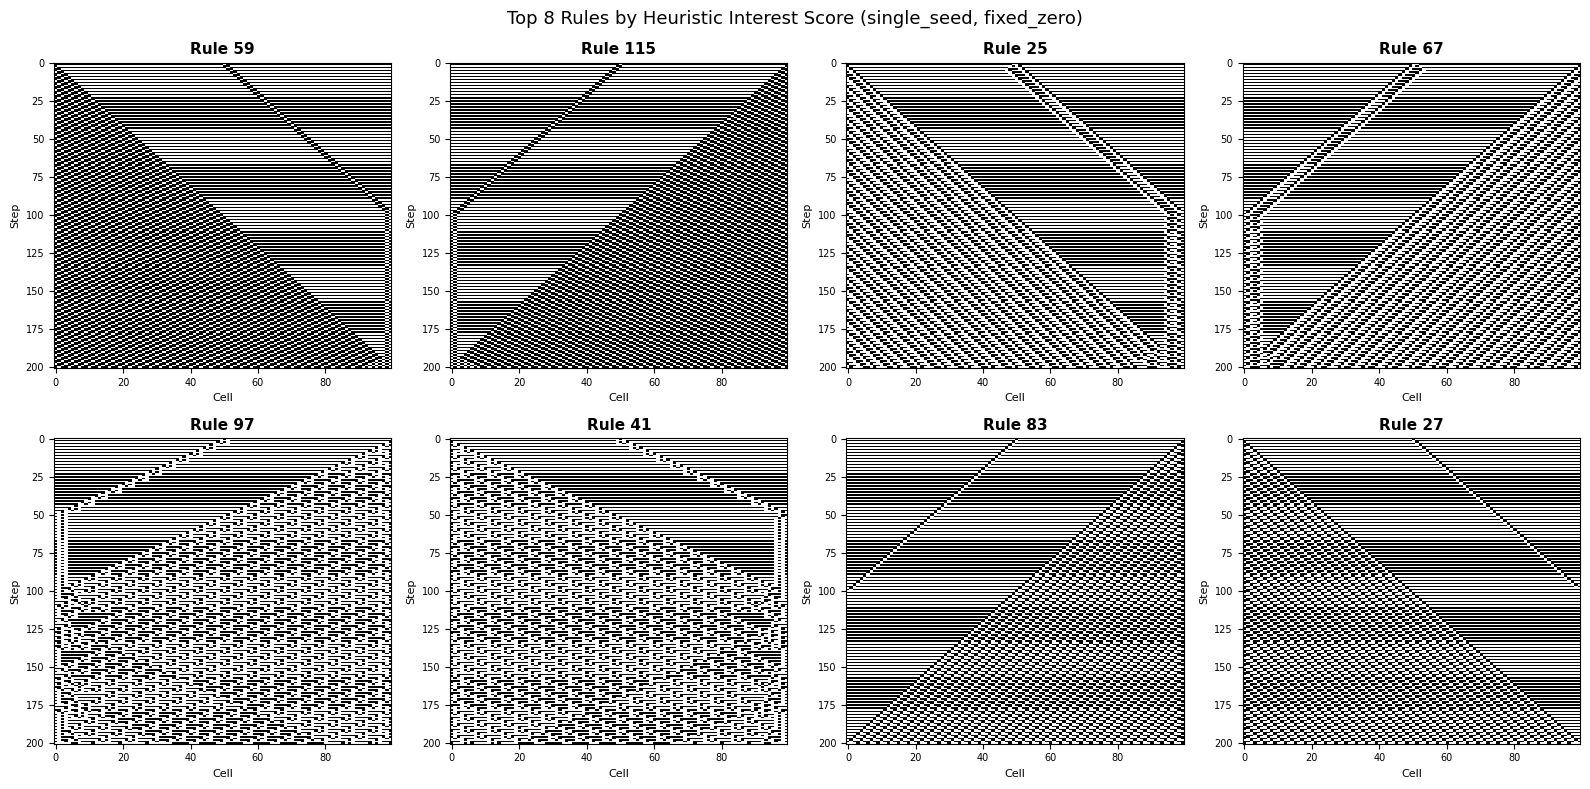

In [10]:
# Visualize the top 8 rules by interest score
top_8 = top_rules.head(8).index.tolist()

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle(
    'Top 8 Rules by Heuristic Interest Score (single_seed, fixed_zero)',
    fontsize=13
)

for ax, rule_num in zip(axes.flatten(), top_8):
    plot_rule(rule_num, all_grids[rule_num], ax)

plt.tight_layout()
plt.show()

## Structured Experiment Summaries

Each summary separates factual **observation** and **metrics** from unfilled placeholders.
The three placeholder fields are intentionally empty — they are designed to be populated
by a SYNTRAN AIEOS agent in a future workflow step.

| Field | Content |
|---|---|
| `observation` | Factual description of what was simulated |
| `metrics` | Computed metric values |
| `interpretation_placeholder` | Empty — for LLM to fill |
| `hypothesis_placeholder` | Empty — for LLM to fill |
| `next_experiments_placeholder` | Empty — for LLM to fill |

> **Governance:** No LLM calls are made in this notebook. LLM integration is deferred
> to a separate, governed workflow step where human approval is explicit.

In [11]:
# Generate structured summaries for the six reference rules
summaries = []
for rule_num in KNOWN_RULES:
    summary = experiment_summary(
        rule_number=rule_num,
        grid=all_grids[rule_num],
        parameters={
            'initial_condition': INITIAL_CONDITION,
            'random_seed': RANDOM_SEED,
            'boundary_condition': BOUNDARY,
            'n_cells': N_CELLS,
            'n_steps': N_STEPS,
        },
    )
    summaries.append(summary)

print(f'{len(summaries)} summaries generated.')
print('Summary keys:', list(summaries[0].keys()))

6 summaries generated.
Summary keys: ['experiment_id', 'timestamp_utc', 'rule_number', 'parameters', 'observation', 'metrics', 'interpretation_placeholder', 'hypothesis_placeholder', 'next_experiments_placeholder']


In [12]:
# Display the full structured summary for Rule 30 (chaotic reference rule)
print(json.dumps(summaries[1], indent=2))

{
  "experiment_id": "rule_030_single_seed",
  "timestamp_utc": "2026-06-18T04:59:24.753975Z",
  "rule_number": 30,
  "parameters": {
    "n_cells": 100,
    "n_steps": 200,
    "initial_condition": "single_seed",
    "random_seed": 42,
    "boundary_condition": "fixed_zero"
  },
  "observation": "Rule 30 simulated for 200 steps over 100 cells. Initial condition: single_seed. Boundary condition: fixed_zero. Random seed: 42.",
  "metrics": {
    "density_mean": 0.44602,
    "density_final": 0.5,
    "transition_count": 54.2786,
    "activity_score": 0.34075,
    "entropy_score": 1.959556,
    "periodicity_score": 0.0,
    "compression_ratio": 0.126617
  },
  "interpretation_placeholder": "",
  "hypothesis_placeholder": "",
  "next_experiments_placeholder": []
}


In [13]:
# Generate structured summaries for the top N rules by interest score
# These are the inputs for the Manual AI Hypothesis Loop (see prompts/hypothesis-review.md)
TOP_N = 10
top_n_rules = top_rules.head(TOP_N).index.tolist()

top_summaries = []
for rule_num in top_n_rules:
    summary = experiment_summary(
        rule_number=rule_num,
        grid=all_grids[rule_num],
        parameters={
            'initial_condition': INITIAL_CONDITION,
            'random_seed': RANDOM_SEED,
            'boundary_condition': BOUNDARY,
            'n_cells': N_CELLS,
            'n_steps': N_STEPS,
        },
    )
    top_summaries.append(summary)

# Serialize to JSON -- paste this into prompts/hypothesis-review.md
# as the {{EXPERIMENT_SUMMARIES_JSON}} placeholder
ai_loop_json = summaries_to_json(top_summaries)

print(f"{len(top_summaries)} summaries ready for AI hypothesis loop.")
print(f"Rules: {top_n_rules}")
print()
print(ai_loop_json)

10 summaries ready for AI hypothesis loop.
Rules: [59, 115, 25, 67, 97, 41, 83, 27, 107, 121]

[
  {
    "experiment_id": "rule_059_single_seed",
    "timestamp_utc": "2026-06-18T04:59:24.839705Z",
    "rule_number": 59,
    "parameters": {
      "n_cells": 100,
      "n_steps": 200,
      "initial_condition": "single_seed",
      "random_seed": 42,
      "boundary_condition": "fixed_zero"
    },
    "observation": "Rule 59 simulated for 200 steps over 100 cells. Initial condition: single_seed. Boundary condition: fixed_zero. Random seed: 42.",
    "metrics": {
      "density_mean": 0.585075,
      "density_final": 0.65,
      "transition_count": 35.3333,
      "activity_score": 0.8273,
      "entropy_score": 3.243453,
      "periodicity_score": 0.0,
      "compression_ratio": 0.02194
    },
    "interpretation_placeholder": "",
    "hypothesis_placeholder": "",
    "next_experiments_placeholder": []
  },
  {
    "experiment_id": "rule_115_single_seed",
    "timestamp_utc": "2026-06-18

## AI Hypothesis Loop — Placeholder

This section is reserved for LLM-assisted hypothesis generation.

**Intended workflow (not yet implemented):**

1. The structured summaries above are passed to an LLM as context.
2. The LLM proposes falsifiable hypotheses about rule behavior.
3. Hypotheses are stored as structured artifacts, separate from simulation outputs.
4. A human operator reviews hypotheses and selects the next experiments.
5. Selected experiments run in the next notebook iteration.

**Governance:**
- No LLM calls are embedded in this notebook.
- LLM integration will follow SYNTRAN AIEOS secure invocation conventions.
- Human operator retains final authority over experiment selection and conclusions.
- All LLM outputs will be stored as reviewable artifacts, not treated as ground truth.

**To trigger the next step (v2):**

```
/synw-agent-python-engineer
/synw-skill-develop

Relevant domains:
- cellular-automata
- scientific-research

Task:
Implement the LLM hypothesis review step for cellauto-lab.
Pass the structured summaries from notebook 001 to a SYNTRAN AIEOS agent.
Store LLM output as a structured artifact. Do not treat it as ground truth.
```

In [14]:
# Placeholder inputs for the future LLM hypothesis loop
ai_hypothesis_loop_inputs = {
    'research_question': (
        'Can an LLM-assisted workflow systematically explore ECA rules, '
        'measure emergent behavioral properties, and generate structured, '
        'falsifiable hypotheses?'
    ),
    'summaries': summaries,
    'instructions': [
        'Review the structured summaries.',
        'Identify rules with anomalous or interesting metrics.',
        'Propose falsifiable hypotheses for each candidate rule.',
        'Suggest next experiments to test each hypothesis.',
        'Do not claim certainty from single-run results.',
        'Cite only verified references.',
    ],
    'status': 'PLACEHOLDER — LLM integration not yet implemented',
}

print('AI Hypothesis Loop inputs prepared.')
n_sums = len(ai_hypothesis_loop_inputs['summaries'])
print(f'Summaries queued: {n_sums}')
status = ai_hypothesis_loop_inputs['status']
print(f'Status: {status}')

AI Hypothesis Loop inputs prepared.
Summaries queued: 6
Status: PLACEHOLDER — LLM integration not yet implemented
